#  UFRN
## Disciplina: Processos estocásticos



Prof. ALLAN DE MEDEIROS MARTINS

Discentes:

DANIELA MAIA DA SILVA

JOSE AUGUSTO AGRIPINO DE OLIVEIRA

WILSON FRANCELINO DE MORAIS JÚNIOR

PPGEEC - UFRN
2024-2


## Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

folder_path = '/content/drive/My Drive/Dataset/'
audio_files = os.listdir(folder_path)
print("Arquivos na pasta:", audio_files)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Dataset/'

## Primeiro e segundo momento




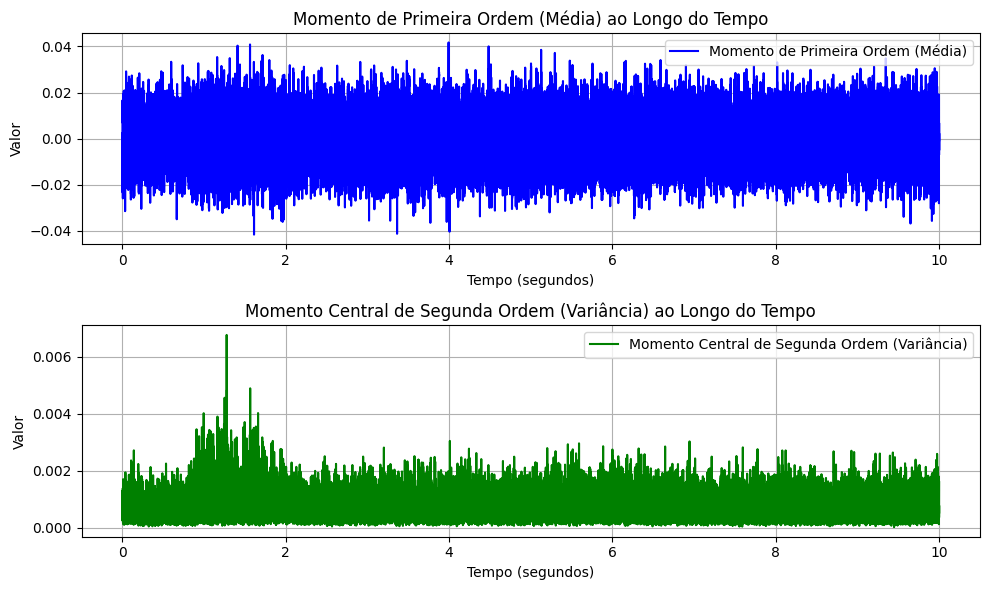

Momento de Primeira Ordem (Média): [ 0.00718079  0.01141663  0.01654968 ... -0.00304565 -0.00424194
 -0.00178528]
Momento de Segunda Ordem (Média do Quadrado): [0.0007803  0.00080793 0.00056477 ... 0.00058245 0.00044206 0.00053529]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

realizacoes = []

for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio com a taxa de amostragem original
    realizacoes.append(y)

# Calcular os instantes de tempo (em segundos)
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])
tempo = np.linspace(0, min_length / sr, min_length)

# Calcular o momento de primeira ordem (média)
momento_primeira_ordem = np.mean(realizacoes, axis=0)  # Média em cada instante (ao longo das realizações)

# Calcular o momento de segunda ordem (média do quadrado)
momento_segunda_ordem = np.var(realizacoes, axis=0)  # Média do quadrado em cada instante

# Calcular o momento central de segunda ordem (variância)
#momento_central_segunda_ordem = momento_segunda_ordem - momento_primeira_ordem**2

plt.figure(figsize=(10, 6))

# Plotar momento de primeira ordem (média)
plt.subplot(2, 1, 1)
plt.plot(tempo, momento_primeira_ordem, label="Momento de Primeira Ordem (Média)", color='blue')
plt.title("Momento de Primeira Ordem (Média) ao Longo do Tempo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

# Plotar momento de segunda ordem (variância)
plt.subplot(2, 1, 2)
plt.plot(tempo, momento_segunda_ordem, label="Momento Central de Segunda Ordem (Variância)", color='green')
plt.title("Momento Central de Segunda Ordem (Variância) ao Longo do Tempo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# Exibir os resultados numéricos
print("Momento de Primeira Ordem (Média):", momento_primeira_ordem)
print("Momento de Segunda Ordem (Média do Quadrado):", momento_segunda_ordem)
#print("Momento Central de Segunda Ordem (Variância):", momento_central_segunda_ordem)


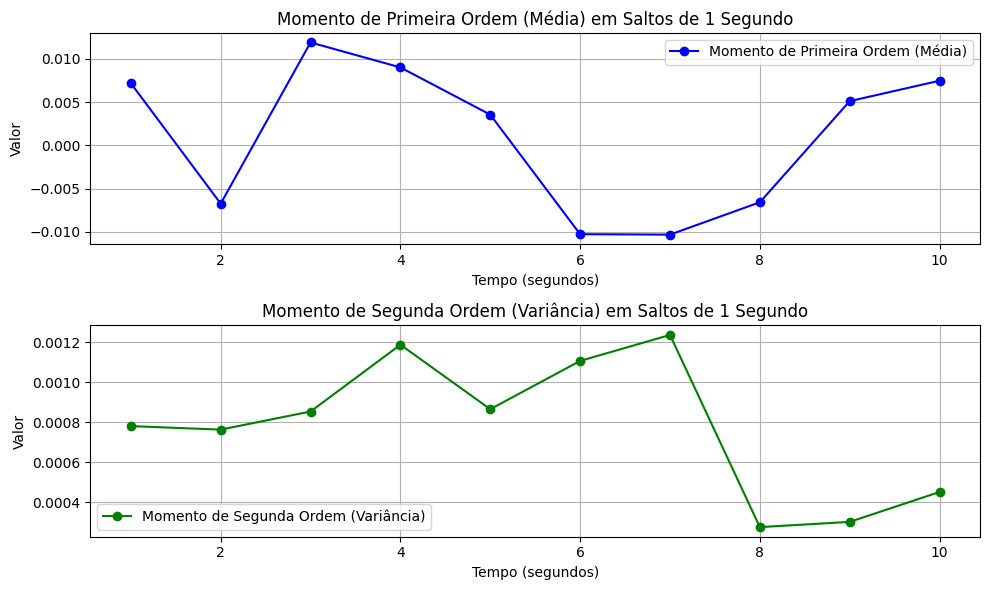

Momentos de Primeira Ordem (Média) em cada segundo: [ 0.00718079 -0.00675049  0.01189575  0.00900574  0.00354004 -0.01028442
 -0.01033325 -0.00659485  0.00510559  0.00746765]
Momentos de Segunda Ordem (Variância) em cada segundo: [0.0007803  0.00076292 0.0008532  0.00118642 0.00086477 0.00110568
 0.00123526 0.00027637 0.00030248 0.00045159]


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

# Caminho da pasta com os áudios
folder_path = '/content/drive/My Drive/Dataset/'
audio_files = [file for file in os.listdir(folder_path) if file.endswith(('.wav', '.mp3'))]

# Inicializar lista para armazenar os sinais carregados
realizacoes = []

# Carregar os áudios
for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio completo
    realizacoes.append(y)

# Padronizar o comprimento dos sinais para o menor tamanho
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])  # Cortar para o menor comprimento

# Criar os índices correspondentes aos instantes de 1 segundo
time_indices = np.arange(0, 10) * sr  # Índices em saltos de 1 segundo

# Calcular os momentos apenas nos pontos de tempo selecionados
momentos_primeira_ordem = []
momentos_segunda_ordem = []

for t in time_indices:
    valores_t = realizacoes[:, t]  # Valores de todas as realizações no instante t
    momento_1 = np.mean(valores_t)  # Momento de primeira ordem (média)
    momento_2 = np.var(valores_t)  # Momento de segunda ordem (variância)
    momentos_primeira_ordem.append(momento_1)
    momentos_segunda_ordem.append(momento_2)

# Converter para arrays
momentos_primeira_ordem = np.array(momentos_primeira_ordem)
momentos_segunda_ordem = np.array(momentos_segunda_ordem)

# Plotar os momentos de primeira e segunda ordem
tempo = np.arange(1, 11)  # Vetor de tempo (1 segundo a 10 segundos)

plt.figure(figsize=(10, 6))

# Momento de primeira ordem
plt.subplot(2, 1, 1)
plt.plot(tempo, momentos_primeira_ordem, label="Momento de Primeira Ordem (Média)", color='blue', marker='o')
plt.title("Momento de Primeira Ordem (Média) em Saltos de 1 Segundo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

# Momento de segunda ordem
plt.subplot(2, 1, 2)
plt.plot(tempo, momentos_segunda_ordem, label="Momento de Segunda Ordem (Variância)", color='green', marker='o')
plt.title("Momento de Segunda Ordem (Variância) em Saltos de 1 Segundo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# Exibir os resultados numéricos
print(f"Momentos de Primeira Ordem (Média) em cada segundo: {momentos_primeira_ordem}")
print(f"Momentos de Segunda Ordem (Variância) em cada segundo: {momentos_segunda_ordem}")


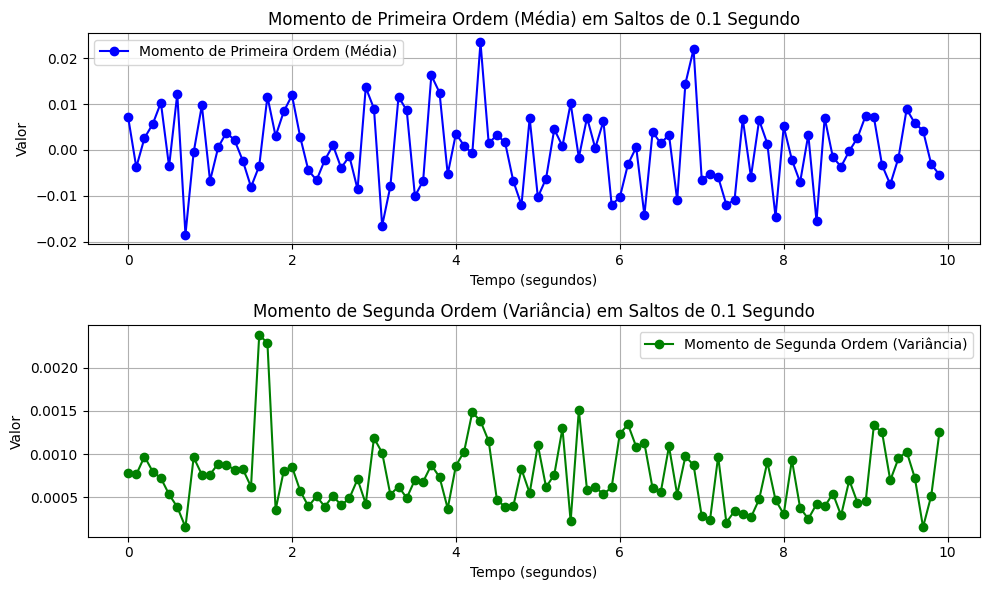

Momentos de Primeira Ordem (Média) em saltos de 0.1 segundo: [ 0.00718079 -0.00377808  0.00260315  0.00560913  0.01029663 -0.00360107
  0.01219788 -0.01844788 -0.00052185  0.00969849 -0.00675049  0.00061035
  0.00378113  0.00210876 -0.00237427 -0.00807495 -0.00348511  0.01163025
  0.00299683  0.00839233  0.01189575  0.00281372 -0.00446167 -0.00657349
 -0.00221252  0.00099792 -0.00391846 -0.00136108 -0.00857544  0.0136261
  0.00900574 -0.01651611 -0.00796509  0.01159058  0.0085968  -0.01006165
 -0.00675049  0.01624451  0.01250305 -0.0052948   0.00354004  0.00092773
 -0.00074768  0.02341614  0.00145874  0.00325317  0.00163574 -0.0067749
 -0.01199646  0.00691833 -0.01028442 -0.00625     0.00451965  0.00081177
  0.01014099 -0.00167236  0.00704956  0.00038452  0.00626221 -0.01192627
 -0.01033325 -0.00310059  0.00056152 -0.01423035  0.00394287  0.00141907
  0.00332336 -0.01097717  0.01441345  0.02195435 -0.00659485 -0.00514832
 -0.0059082  -0.01195068 -0.01087646  0.00679321 -0.00585938  0.0

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

# Caminho da pasta com os áudios
folder_path = '/content/drive/My Drive/Dataset/'
audio_files = [file for file in os.listdir(folder_path) if file.endswith(('.wav', '.mp3'))]

# Inicializar lista para armazenar os sinais carregados
realizacoes = []

# Carregar os áudios
for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio completo
    realizacoes.append(y)

# Padronizar o comprimento dos sinais para o menor tamanho
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])  # Cortar para o menor comprimento

# Criar os índices correspondentes aos instantes de 0.1 segundo
total_time = min_length / sr  # Tempo total em segundos
time_indices = np.arange(0, total_time, 0.1) * sr  # Índices em saltos de 0.1 segundo
time_indices = time_indices.astype(int)  # Converter para inteiros

# Calcular os momentos apenas nos pontos de tempo selecionados
momentos_primeira_ordem = []
momentos_segunda_ordem = []

for t in time_indices:
    valores_t = realizacoes[:, t]  # Valores de todas as realizações no instante t
    momento_1 = np.mean(valores_t)  # Momento de primeira ordem (média)
    momento_2 = np.var(valores_t)  # Momento de segunda ordem (variância)
    momentos_primeira_ordem.append(momento_1)
    momentos_segunda_ordem.append(momento_2)

# Converter para arrays
momentos_primeira_ordem = np.array(momentos_primeira_ordem)
momentos_segunda_ordem = np.array(momentos_segunda_ordem)

# Plotar os momentos de primeira e segunda ordem
tempo = np.arange(0, total_time, 0.1)  # Vetor de tempo (0.1 segundo a 10 segundos)

plt.figure(figsize=(10, 6))

# Momento de primeira ordem
plt.subplot(2, 1, 1)
plt.plot(tempo, momentos_primeira_ordem, label="Momento de Primeira Ordem (Média)", color='blue', marker='o')
plt.title("Momento de Primeira Ordem (Média) em Saltos de 0.1 Segundo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

# Momento de segunda ordem
plt.subplot(2, 1, 2)
plt.plot(tempo, momentos_segunda_ordem, label="Momento de Segunda Ordem (Variância)", color='green', marker='o')
plt.title("Momento de Segunda Ordem (Variância) em Saltos de 0.1 Segundo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Valor")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# Exibir os resultados numéricos
print(f"Momentos de Primeira Ordem (Média) em saltos de 0.1 segundo: {momentos_primeira_ordem}")
print(f"Momentos de Segunda Ordem (Variância) em saltos de 0.1 segundo: {momentos_segunda_ordem}")


In [ ]:
import numpy as np
from scipy.stats import entropy

def calculate_joint_entropy(realizations):
    """
    Calcula a entropia conjunta de um sistema estocástico com múltiplos instantes de tempo.

    Args:
    - realizations (2D array): Matriz de realizações, onde cada linha é uma realização e
      cada coluna é um instante de tempo.

    Returns:
    - joint_entropy (float): Entropia conjunta calculada para o sistema.
    """
    # Obter a probabilidade conjunta dos valores de todas as variáveis
    # Cada coluna de realizations é um instante de tempo, então pegamos todas as colunas
    joint_values, joint_counts = np.unique(realizations, axis=0, return_counts=True)
    joint_probabilities = joint_counts / joint_counts.sum()  # Probabilidade conjunta

    # Calcular a entropia conjunta
    joint_entropy = entropy(joint_probabilities, base=2)

    return joint_entropy

# Exemplo de realizações (10 realizações ao longo de 5 instantes de tempo)
realizations = np.array([
    [0, 1, 1, 0, 1],
    [0, 1, 0, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 1, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1],
])

# Calcular a entropia conjunta para o sistema
joint_entropy = calculate_joint_entropy(realizations)
print("Entropia conjunta do sistema:", joint_entropy)


Entropia conjunta do sistema: 2.7219280948873625



## Covariância

Matriz de Correlação para instantes de 0.1 segundos:
[[ 8.67001723e-04 -2.45944555e-04 -4.92030330e-04 ... -7.04780738e-05
  -4.18811333e-04  2.82512916e-04]
 [-2.45944555e-04  8.48311890e-04 -2.84658910e-04 ...  7.44038572e-05
   1.89902592e-04 -2.04556042e-04]
 [-4.92030330e-04 -2.84658910e-04  1.07945068e-03 ... -2.06316335e-04
   1.06510996e-04 -2.50267651e-04]
 ...
 [-7.04780738e-05  7.44038572e-05 -2.06316335e-04 ...  1.70067046e-04
   1.30940084e-04 -1.20108968e-04]
 [-4.18811333e-04  1.89902592e-04  1.06510996e-04 ...  1.30940084e-04
   5.73523177e-04 -1.35825947e-05]
 [ 2.82512916e-04 -2.04556042e-04 -2.50267651e-04 ... -1.20108968e-04
  -1.35825947e-05  1.39425774e-03]]


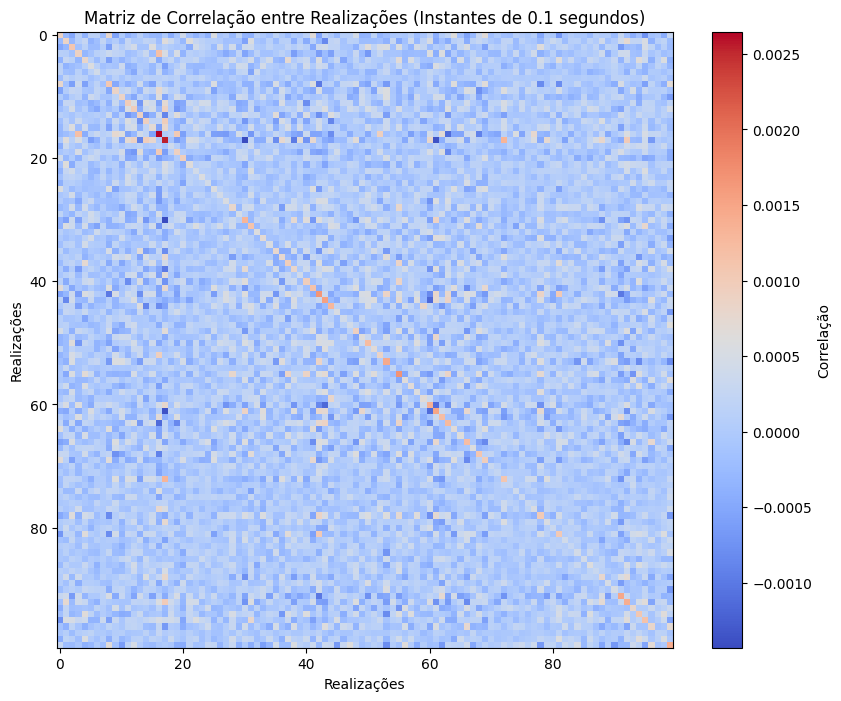

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

# Caminho da pasta com os áudios
folder_path = '/content/drive/My Drive/Dataset/'
audio_files = [file for file in os.listdir(folder_path) if file.endswith(('.wav', '.mp3'))]

# Inicializar lista para armazenar os sinais carregados
realizacoes = []

# Carregar os áudios
for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio completo
    realizacoes.append(y)

# Padronizar o comprimento dos sinais para o menor tamanho
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])  # Cortar para o menor comprimento

# Criar os índices correspondentes aos instantes de 0.1 segundo
total_time = min_length / sr  # Tempo total em segundos
time_indices = np.arange(0, total_time, 0.1) * sr  # Índices em saltos de 0.1 segundo
time_indices = time_indices.astype(int)  # Converter para inteiros

# Selecionar os valores das realizações apenas nos instantes de 0.1 segundo
valores_tempo = realizacoes[:, time_indices]

valores_tempo_transposto = valores_tempo.T

# Calcular a matriz de correlação
correlation_matrix = np.cov(valores_tempo_transposto)

# Exibir a matriz de correlação
print("Matriz de Correlação para instantes de 0.1 segundos:")
print(correlation_matrix)

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlação")
plt.title("Matriz de Correlação entre Realizações (Instantes de 0.1 segundos)")
plt.xlabel("Realizações")
plt.ylabel("Realizações")
plt.show()


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

# Caminho da pasta com os áudios
folder_path = '/content/drive/My Drive/Dataset/'
audio_files = [file for file in os.listdir(folder_path) if file.endswith(('.wav', '.mp3'))]

# Inicializar lista para armazenar os sinais carregados
realizacoes = []

# Carregar os áudios
for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio completo
    realizacoes.append(y)

# Padronizar o comprimento dos sinais para o menor tamanho
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])  # Cortar para o menor comprimento

# Criar os índices correspondentes aos instantes de 0.1 segundo
total_time = min_length / sr  # Tempo total em segundos
time_indices = np.arange(0, total_time, 0.5) * sr  # Índices em saltos de 0.1 segundo
time_indices = time_indices.astype(int)  # Converter para inteiros

# Selecionar os valores das realizações apenas nos instantes de 0.1 segundo
valores_tempo = realizacoes[:, time_indices]

valores_tempo_transposto = valores_tempo.T

# Calcular a matriz de correlação
correlation_matrix = np.cov(valores_tempo_transposto)

# Exibir a matriz de correlação
print("Matriz de Correlação para instantes de 0.1 segundos:")
print(correlation_matrix)

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlação")
plt.title("Matriz de Correlação entre Realizações (Instantes de 0.1 segundos)")
plt.xlabel("Realizações")
plt.ylabel("Realizações")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Dataset/'

In [ ]:
import numpy as np

def is_toeplitz(matrix):
    """
    Verifica se uma matriz é uma matriz de Toeplitz.

    Args:
        matrix (np.ndarray): Matriz para testar.

    Returns:
        bool: True se a matriz for Toeplitz, False caso contrário.
    """
    rows, cols = matrix.shape

    # Verificar cada diagonal principal
    for i in range(rows - 1):
        for j in range(cols - 1):
            if matrix[i, j] != matrix[i + 1, j + 1]:
                return False  # A matriz não é Toeplitz
    return True

# Exemplo de uso
matriz = correlation_matrix

if is_toeplitz(matriz):
    print("A matriz é de Toeplitz.")
else:
    print("A matriz NÃO é de Toeplitz.")


A matriz NÃO é de Toeplitz.


##Estacionariedade

In [ ]:
np.arange(0, total_time, 0.1)

NameError: name 'total_time' is not defined

## Entropia

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


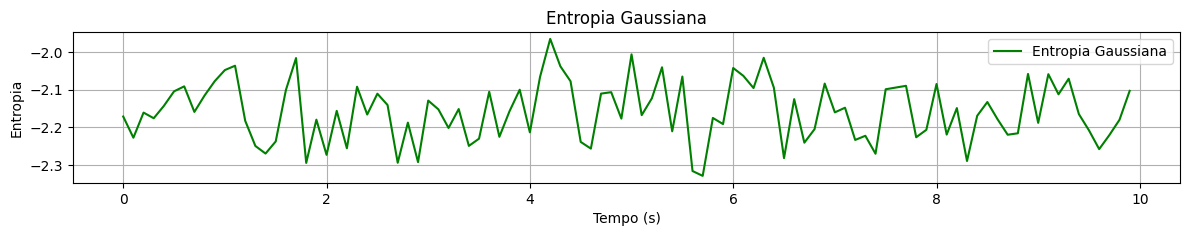

In [ ]:
import os
import librosa
import numpy as np
import math
import matplotlib.pyplot as plt

# Caminho da pasta com os áudios
from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/Dataset/'
audio_files = os.listdir(folder_path)



# Inicializar lista para armazenar os sinais carregados
realizacoes = []

# Carregar os áudios
for audio_file in audio_files:
    audio_path = os.path.join(folder_path, audio_file)
    y, sr = librosa.load(audio_path, sr=None)  # Carregar o áudio completo
    realizacoes.append(y)

# Padronizar o comprimento dos sinais para o menor tamanho
min_length = min(len(r) for r in realizacoes)
realizacoes = np.array([r[:min_length] for r in realizacoes])  # Cortar para o menor comprimento

# Criar os índices correspondentes aos instantes de 0.1 segundo
total_time = min_length / sr  # Tempo total em segundos
time_indices = np.arange(0, total_time, 0.1) * sr  # Índices em saltos de 0.1 segundo
time_indices = time_indices.astype(int)  # Converter para inteiros

# Calcular os momentos apenas nos pontos de tempo selecionados
momentos_primeira_ordem = []
momentos_segunda_ordem = []
valores_tempo = np.empty((0, len(realizacoes[:, 1])), dtype=realizacoes.dtype)  # Forma inicial (0, número de colunas)

for t in time_indices:
    valores_t = realizacoes[:, t]  # Valores de todas as realizações no instante t
    momento_1 = np.mean(valores_t)  # Momento de primeira ordem (média)
    momento_2 = np.var(valores_t)  # Momento de segunda ordem (variância)
    valores_tempo = np.vstack([valores_tempo, valores_t])  # Adicionar a linha
    momentos_primeira_ordem.append(momento_1)
    momentos_segunda_ordem.append(momento_2)

# Converter para arrays
momentos_primeira_ordem = np.array(momentos_primeira_ordem)
momentos_segunda_ordem = np.array(momentos_segunda_ordem)

# Calcular a entropia contínua utilizando variâncias
def calculate_entropy(momentos_variancia):
    """
    Calcula a entropia Gaussiana de um processo estocástico contínuo.

    Args:
    - momentos_variancia (list or np.array): Variância de cada instante de tempo.

    Returns:
    - entropies (list): Lista de entropias calculadas.
    """
    entropies = []
    epsilon = 1e-8
    for var in momentos_variancia:
        std = max(np.sqrt(var), epsilon)  # Garante que a variância não seja zero
        entropy = math.log(math.sqrt(2 * math.pi * math.e) * std)
        entropies.append(entropy)
    return entropies

# Calcular a entropia para os instantes de tempo
entropies_continuous = calculate_entropy(momentos_segunda_ordem)

# Plotar os momentos e entropia
tempo = np.arange(0, total_time, 0.1)  # Vetor de tempo (0.1 segundo a 10 segundos)

plt.figure(figsize=(12, 6))

# Plotar entropia
plt.subplot(3, 1, 3)
plt.plot(tempo, entropies_continuous, label='Entropia Gaussiana', color='green')
plt.title('Entropia Gaussiana')
plt.xlabel('Tempo (s)')
plt.ylabel('Entropia')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
